In [25]:
import os
import json
import torch
import pandas as pd
import logging
import importlib
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from IPython.display import Image

import sys
PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
SRC_DIR = str(PROJECT_DIR / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import multiomic_transformer.utils.data_formatter as data_formatter
import multiomic_transformer.utils.experiment_handler as experiment_handler

random.seed(1337)
np.random.seed(1337)
torch.manual_seed(1337)

GROUND_TRUTH_DIR = PROJECT_DIR / "data" / "ground_truth_files"

In [26]:
def load_ground_truth(ground_truth_file):
    if type(ground_truth_file) == str:
        ground_truth_file = Path(ground_truth_file)
        
    if ground_truth_file.suffix == ".csv":
        sep = ","
    elif ground_truth_file.suffix == ".tsv":
        sep="\t"
        
    ground_truth_df = pd.read_csv(ground_truth_file, sep=sep, on_bad_lines="skip", engine="python")
    
    if "chip" in ground_truth_file.name and "atlas" in ground_truth_file.name:
        ground_truth_df = ground_truth_df[["source_id", "target_id"]]

    if ground_truth_df.columns[0] != "Source" or ground_truth_df.columns[1] != "Target":
        ground_truth_df = ground_truth_df.rename(columns={ground_truth_df.columns[0]: "Source", ground_truth_df.columns[1]: "Target"})
    ground_truth_df["Source"] = ground_truth_df["Source"].astype(str).str.upper()
    ground_truth_df["Target"] = ground_truth_df["Target"].astype(str).str.upper()
    
    # Build TF, TG, and edge sets for quick lookup later
    gt = ground_truth_df[["Source", "Target"]].dropna()

    gt_tfs = set(gt["Source"].unique())
    gt_tgs = set(gt["Target"].unique())
    
    gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
        
    return ground_truth_df, gt_lookup

gt_by_dataset_dict = {
    # "Macrophage": {
    #     # "RN204": load_ground_truth(GROUND_TRUTH_DIR / "rn204_macrophage_human_chipseq.tsv"),
    #     "ChIP-Atlas macrophage": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_macrophage.csv"),
    # },
    "mESC": {
        "ChIP-Atlas mESC": load_ground_truth(GROUND_TRUTH_DIR / "chip_atlas_tf_peak_tg_dist.csv"),
        "RN111": load_ground_truth(GROUND_TRUTH_DIR / "RN111.tsv"),
        "RN112": load_ground_truth(GROUND_TRUTH_DIR / "RN112.tsv"),
        "RN114": load_ground_truth(GROUND_TRUTH_DIR / "RN114.tsv"),
        "RN116": load_ground_truth(GROUND_TRUTH_DIR / "RN116.tsv"),        
    },
    # "K562": {
    #     "ChIP-Atlas K562": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_K562.csv"),
    #     "RN117": load_ground_truth(GROUND_TRUTH_DIR / "RN117.tsv"),        
    # },
    # "iPSC": {
    #     # "ChIP-Atlas iPSC": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC.csv"),
    #     "ChIP-Atlas iPSC (1 Mb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_1mb.csv"),
    #     # "ChIP-Atlas iPSC (100 kb)": load_ground_truth(GROUND_TRUTH_DIR / "chipatlas_iPSC_100kb.csv"),
    # }
}

In [27]:
def calculate_auroc_all_sample_gts(exp, df, ground_truth_dict):    
    pooled_auroc = []
    per_tf_auroc = []
    for gt_name, ground_truth in ground_truth_dict.items():
        _, gt_lookup = ground_truth
        
        labeled_df = exp.create_ground_truth_comparison_df(df, gt_lookup, gt_name)
        
        gt_pooled_auroc = exp.quick_pooled_auroc(labeled_df)
        gt_per_tf_auroc = exp.quick_per_tf_auroc(labeled_df)
        
        pooled_auroc.append(gt_pooled_auroc)
        per_tf_auroc.append(gt_per_tf_auroc)

    pooled_median_auroc = np.median(pooled_auroc)
    per_tf_median_auroc = np.median(per_tf_auroc)
        
    auroc_df = pd.DataFrame({
        "pooled_median_auroc": pooled_median_auroc,
        "per_tf_median_auroc": per_tf_median_auroc,
    }, index=[0])
    
    return auroc_df

In [28]:
DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/")

cell_type="mESC"
sample_name="E7.5_rep1"
experiment_name=f"{cell_type}_{sample_name}_tutorial"
organism_code="mm10"

exp = experiment_handler.load_experiment_handler(
    tdf_settings_path=DATA_DIR / "PROCESSED_DATA" / experiment_name / "settings.json",
    experiment_dir=DATA_DIR / "EXPERIMENTS/",
    model_num=1,
)

mESC_E7.5_rep1_tutorial: Loaded existing settings
Loading ExperimentHandler state from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/EXPERIMENTS/mESC_E7.5_rep1_tutorial/model_training_001/experiment_handler_save.json...


In [29]:
atac_grn = exp.load_atac_grn()
atac_grn["Source"] = atac_grn["Source"].str.lower()
atac_grn.rename(columns={"Source": "peak_id"}, inplace=True)

tf_tg_grn = exp.load_grn()

In [31]:
homer_tf_to_peak_df = pd.read_parquet(
    PROJECT_DIR / "dev" / "Homer" / "homer_tf_to_peak.parquet"
)
homer_tf_to_peak_df.rename(columns={"source_id": "Source"}, inplace=True)
homer_tf_to_peak_df[["Source", "peak_id", "homer_binding_score"]]
homer_tf_to_peak_df["Source"] = homer_tf_to_peak_df["Source"].str.upper()

In [32]:
peak_tg_dist_df = pd.read_parquet(exp.tdf.file_paths["samples"][sample_name]["peak_to_gene_dist"])
peak_tg_dist_df = peak_tg_dist_df[["peak_id", "target_id", "TSS_dist"]].rename(columns={"target_id": "Target"})
peak_tg_dist_df.head()

,peak_id,Target,TSS_dist
0,chr9:88480998-88481720,9430037G07RIK,0
1,chr9:50746017-50746871,ALG9,0
2,chr3:89868325-89869122,ATP8B2,0
3,chr6:113283221-113284098,BRPF1,0
4,chr9:107928096-107928874,GM20529,0


In [33]:
def print_dataframes_info(df, name):
    print(f"{name} DataFrame:")
    display(df.head())
    if 'peak_id' in df.columns:
        print(f"Number of unique peaks: {df['peak_id'].nunique()}")
    if 'Source' in df.columns:
        print(f"Number of unique sources: {df['Source'].nunique()}")
    if 'Target' in df.columns:
        print(f"Number of unique targets: {df['Target'].nunique()}")
    print(f"Number of rows: {len(df)}")
    print("-" * 40)

print_dataframes_info(atac_grn, "ATAC GRN")
print_dataframes_info(homer_tf_to_peak_df, "Homer TF-to-Peak")
print_dataframes_info(tf_tg_grn, "TF-TG GRN")
print_dataframes_info(peak_tg_dist_df, "Peak-TG Distance")

ATAC GRN DataFrame:


,peak_id,Target,Score
0,chr1:9795350-9796160,1700034P13RIK,0.445956
1,chr1:9795350-9796160,4930444P10RIK,-2.130716
2,chr1:9795350-9796160,4933439K11RIK,-1.716379
3,chr1:9795350-9796160,A330023F24RIK,0.743872
4,chr1:9795350-9796160,A830018L16RIK,0.464368


Number of unique peaks: 15832
Number of unique targets: 1904
Number of rows: 1797647
----------------------------------------
Homer TF-to-Peak DataFrame:


,peak_id,Source,homer_binding_score
0,chr1:37871749-37872678,ETS,1.0
1,chr5:139275297-139275812,ETS,1.0
2,chr6:128338734-128339434,ETS,1.0
3,chr9:48146374-48147285,ETS,1.0
4,chr3:37757841-37758747,ETS,1.0


Number of unique peaks: 199837
Number of unique sources: 342
Number of rows: 19959062
----------------------------------------
TF-TG GRN DataFrame:


,Source,Target,Score
0,ALX1,1190005I06RIK,-0.099560
1,ALX1,1600010M07RIK,-0.168651
2,ALX1,1700007J10RIK,-0.373860
3,ALX1,1700034P13RIK,-0.298619
4,ALX1,1700057H15RIK,-0.471786


Number of unique sources: 214
Number of unique targets: 1904
Number of rows: 407456
----------------------------------------
Peak-TG Distance DataFrame:


,peak_id,Target,TSS_dist
0,chr9:88480998-88481720,9430037G07RIK,0
1,chr9:50746017-50746871,ALG9,0
2,chr3:89868325-89869122,ATP8B2,0
3,chr6:113283221-113284098,BRPF1,0
4,chr9:107928096-107928874,GM20529,0


Number of unique peaks: 196885
Number of unique targets: 48772
Number of rows: 196885
----------------------------------------


In [34]:
atac_grn.rename(columns={"Score": "atac_tg_grad_score"}, inplace=True)
tf_tg_grn.rename(columns={"Score": "tf_tg_grad_score"}, inplace=True)

# Cast scores to a smaller data type to save memory
homer_tf_to_peak_df["homer_binding_score"] = homer_tf_to_peak_df["homer_binding_score"].astype(np.int8)
tf_tg_grn["tf_tg_grad_score"] = tf_tg_grn["tf_tg_grad_score"].astype(np.float16)
atac_grn["atac_tg_grad_score"] = atac_grn["atac_tg_grad_score"].astype(np.float16)

homer_tf_to_peak_df["Source"] = homer_tf_to_peak_df["Source"].astype(str)
homer_tf_to_peak_df["peak_id"] = homer_tf_to_peak_df["peak_id"].astype(str)

atac_grn["Target"] = atac_grn["Target"].astype(str)
atac_grn["peak_id"] = atac_grn["peak_id"].astype(str)

# ===== Merge peaks from Homer with the ATAC gradient attribution results =====
homer_peaks = pd.Index(homer_tf_to_peak_df["peak_id"].unique())
atac_peaks = pd.Index(atac_grn["peak_id"].unique())

shared_peaks = homer_peaks.intersection(atac_peaks)

print(f"Shared peaks: {len(shared_peaks):,}")
print(f"HOMER unique peaks: {len(homer_peaks):,}")
print(f"ATAC GRN unique peaks: {len(atac_peaks):,}")

homer_shared = homer_tf_to_peak_df[
    homer_tf_to_peak_df["peak_id"].isin(shared_peaks)
].copy()

atac_shared = atac_grn[
    atac_grn["peak_id"].isin(shared_peaks)
].copy()

print("HOMER shared rows:", len(homer_shared))
print("ATAC shared rows:", len(atac_shared))

homer_small = homer_tf_to_peak_df[
    ["peak_id", "Source", "homer_binding_score"]
].drop_duplicates()

joined = atac_grn.merge(
    homer_small,
    on=["peak_id"],
    how="inner",
    sort=False,
    copy=False,
)

print("Joined rows:", len(joined))
print("Joined unique peaks:", joined["peak_id"].nunique())
print("Joined unique sources:", joined["Source"].nunique())
print("Joined unique targets:", joined["Target"].nunique())

Shared peaks: 15,832
HOMER unique peaks: 199,837
ATAC GRN unique peaks: 15,832
HOMER shared rows: 1590286
ATAC shared rows: 1797647
Joined rows: 172967116
Joined unique peaks: 15832
Joined unique sources: 342
Joined unique targets: 1904


In [35]:
# ===== Merge the combined Homer/ATAC GA dataframe with the TF-TG GRN =====
merged_df = tf_tg_grn.merge(joined, on=["Source", "Target"], how="inner")
merged_df = merged_df[["Source", "peak_id", "Target", "tf_tg_grad_score", "atac_tg_grad_score", "homer_binding_score"]]

display(merged_df.head())
print(f"TFs: {merged_df['Source'].nunique()}")
print(f"TG: {merged_df['Target'].nunique()}")
print(f"Edges: {len(merged_df[['Source', 'Target']].drop_duplicates())}")

,Source,peak_id,Target,tf_tg_grad_score,atac_tg_grad_score,homer_binding_score
0,BACH2,chr8:10292225-10293104,1190005I06RIK,0.234497,-0.199829,1
1,BACH2,chr8:10361116-10362032,1190005I06RIK,0.234497,-0.276367,1
2,BACH2,chr8:11258292-11259058,1190005I06RIK,0.234497,-0.276367,1
3,BACH2,chr8:11259674-11260501,1190005I06RIK,0.234497,-0.381348,1
4,BACH2,chr8:11287245-11287996,1190005I06RIK,0.234497,-0.302246,1


TFs: 67
TG: 1904
Edges: 127568


Sources with most edges:
0: PITX1 (1639752 edges)
1: NANOG (1622986 edges)
2: SMAD3 (1446955 edges)
3: EOMES (1213701 edges)
4: TRPS1 (1179726 edges)
5: FOXO1 (1125605 edges)
6: ISL1 (1108820 edges)
7: MEIS1 (1031138 edges)
8: SOX6 (1016457 edges)
9: MYB (988287 edges)
Source: MYB


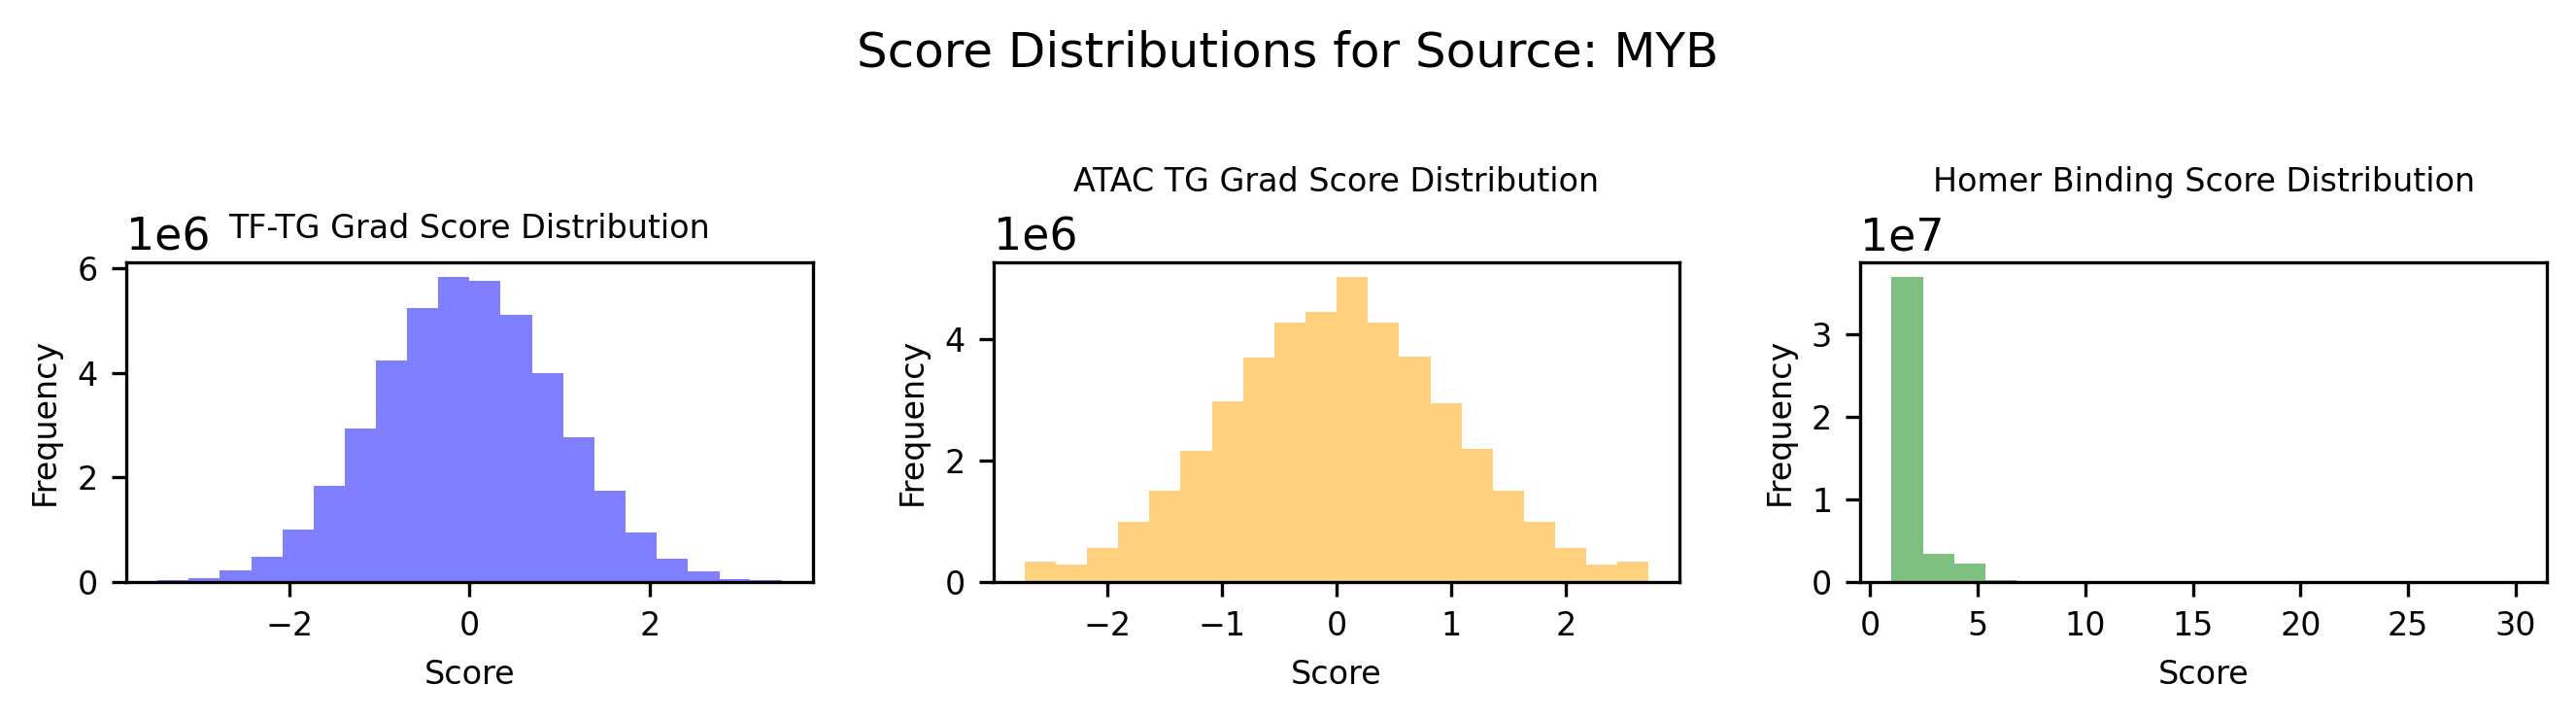

In [66]:
source_num = 1

source_counts = merged_df["Source"].value_counts()
tf_most_edges = source_counts.index.tolist()

print("Sources with most edges:")
for i, source in enumerate(tf_most_edges[:10]):
    print(f"{i}: {source} ({source_counts[source]} edges)")

edge_df = merged_df.copy()

print(f"Source: {source}")

fig, ax = plt.subplots(1, 3, figsize=(9, 2.5))
ax[0].hist(edge_df["tf_tg_grad_score"], bins=20, alpha=0.5, label="TF-TG Grad Score", color="blue")
ax[0].set_title("TF-TG Grad Score Distribution", fontsize=8)
ax[0].set_xlabel("Score", fontsize=8)
ax[0].set_ylabel("Frequency", fontsize=8)
ax[0].tick_params(axis='both', which='major', labelsize=8)

ax[1].hist(edge_df["atac_tg_grad_score"], bins=20, alpha=0.5, label="ATAC TG Grad Score", color="orange")
ax[1].set_title("ATAC TG Grad Score Distribution", fontsize=8)
ax[1].set_xlabel("Score", fontsize=8)
ax[1].set_ylabel("Frequency", fontsize=8)
ax[1].tick_params(axis='both', which='major', labelsize=8)

ax[2].hist(edge_df["homer_binding_score"], bins=20, alpha=0.5, label="Homer Binding Score", color="green")
ax[2].set_title("Homer Binding Score Distribution", fontsize=8)
ax[2].set_xlabel("Score", fontsize=8)
ax[2].set_ylabel("Frequency", fontsize=8)
ax[2].tick_params(axis='both', which='major', labelsize=8)

plt.suptitle(f"Score Distributions for Source: {source}", fontsize=12)
plt.tight_layout()
fig.show()

In [ ]:
grn_df = merged_df.groupby(["Source", "Target"]).agg({
    "tf_tg_grad_score": "mean",
    "atac_tg_grad_score": "mean",
    "homer_binding_score": "mean"
}).reset_index()

def normalize_scores(score_series):
    min_score = score_series.min()
    max_score = score_series.max()
    if max_score > min_score:
        return (score_series - min_score) / (max_score - min_score)
    else:
        return pd.Series(1.0, index=score_series.index)

score_cols = [
    "tf_tg_grad_score",
    "atac_tg_grad_score",
    "homer_binding_score",
]

for col in score_cols:
    grn_df[f"{col}_norm"] = normalize_scores(grn_df[col])

eps = 1e-6
grn_df["Score"] = (
    grn_df["tf_tg_grad_score_norm"].clip(lower=eps)
    * grn_df["atac_tg_grad_score_norm"].clip(lower=eps)
    * grn_df["homer_binding_score_norm"].clip(lower=eps)
)

grn_df = grn_df[["Source", "Target", "Score"]].sort_values(by="Score", ascending=False).reset_index(drop=True)

grn_df.head()


ChIP-Atlas mESC
  overlapping TFs: 25
  overlapping targets: 1860

RN111
  overlapping TFs: 12
  overlapping targets: 1765

RN112
  overlapping TFs: 11
  overlapping targets: 1451

RN114
  overlapping TFs: 6
  overlapping targets: 1519

RN116
  overlapping TFs: 6
  overlapping targets: 730
Pooled Median AUROC: 0.4921
Per-TF Median AUROC: 0.5698


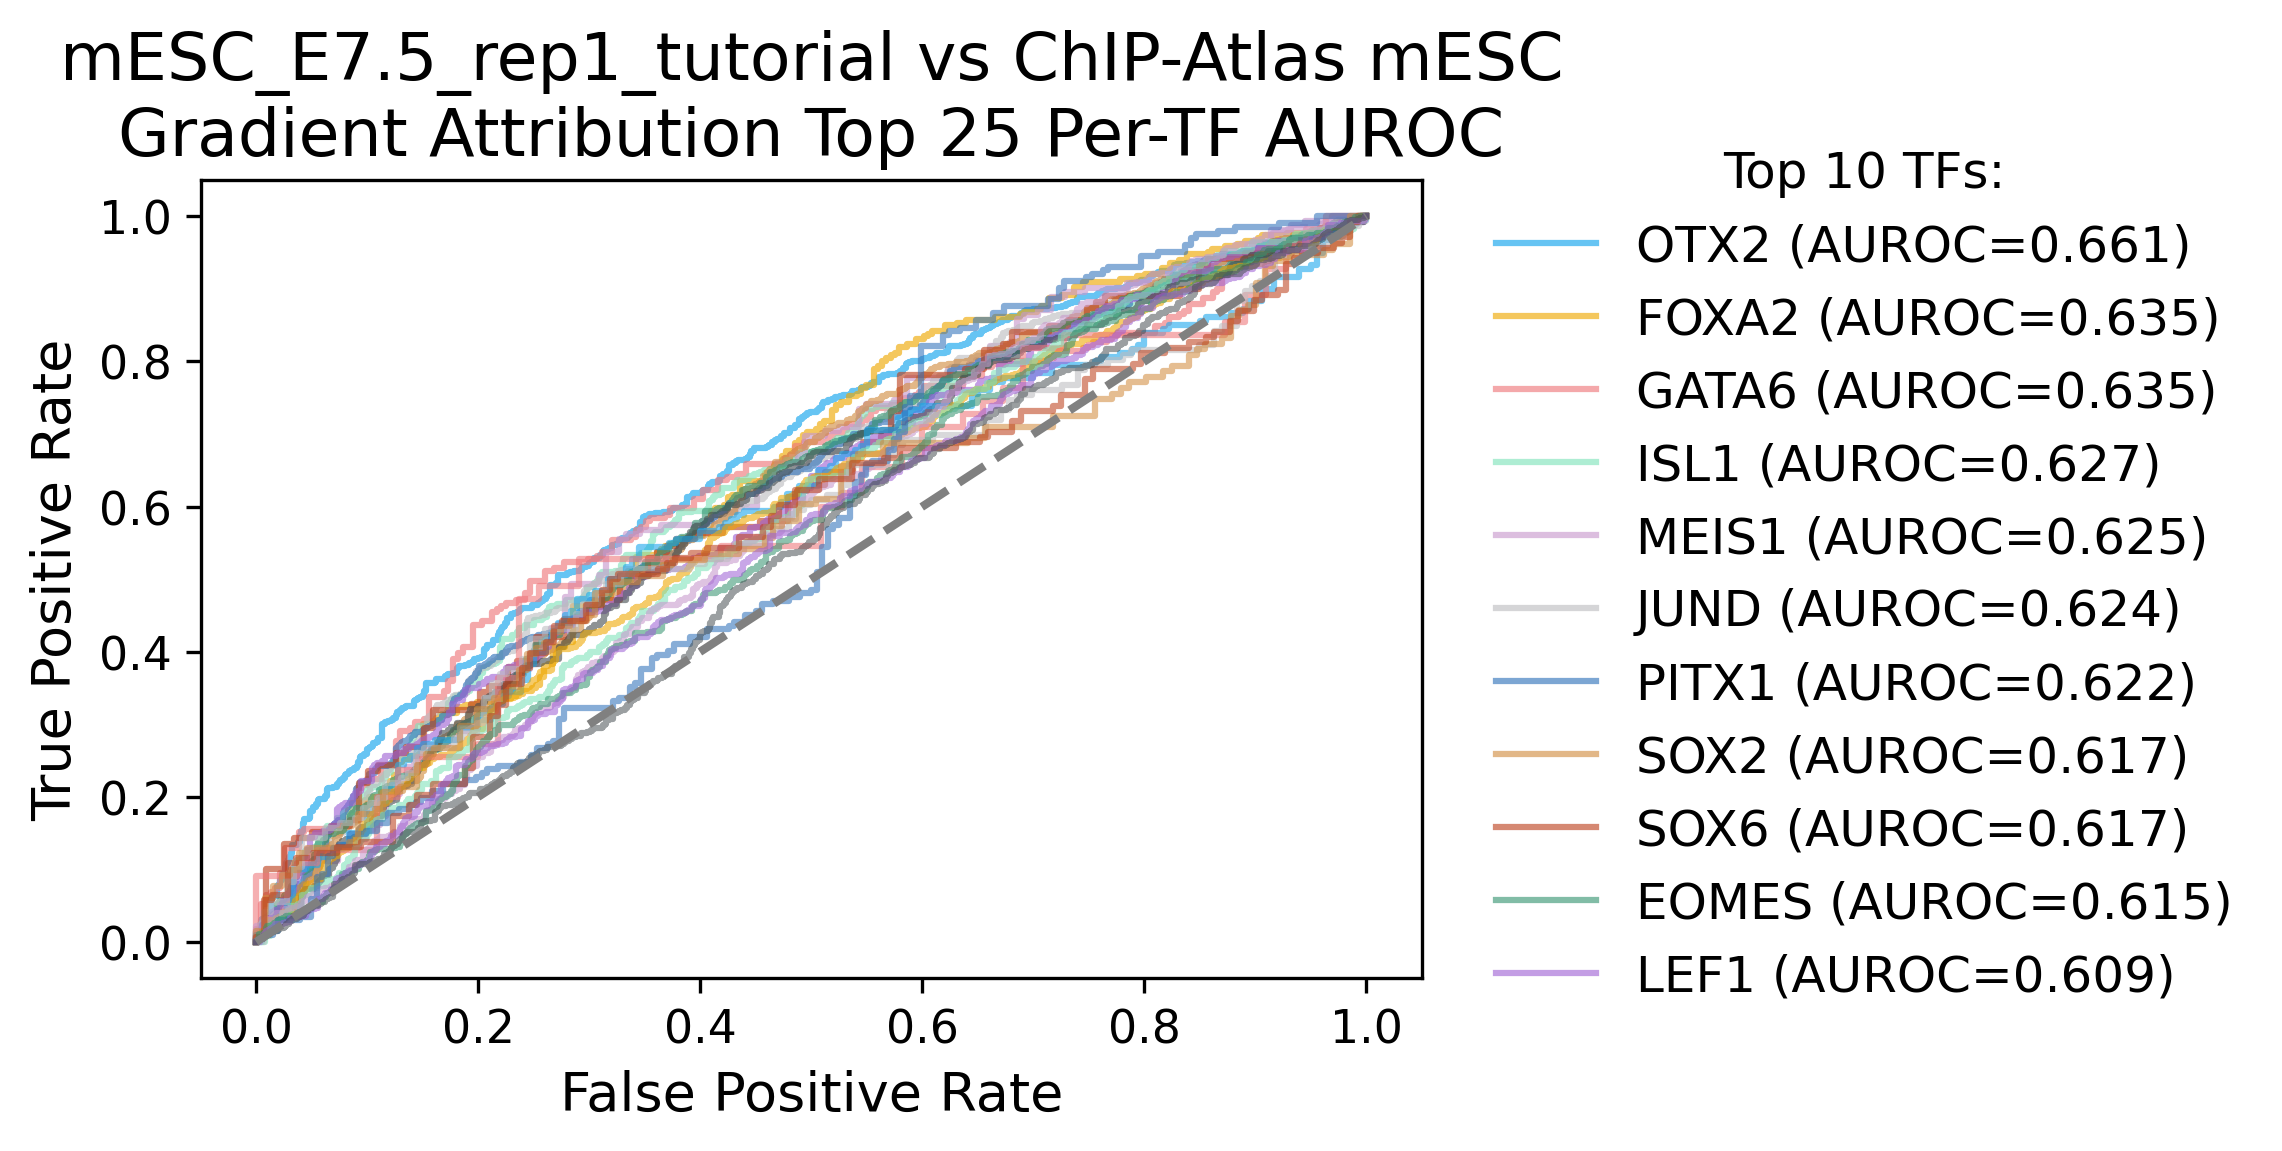

In [64]:
auroc_df = calculate_auroc_all_sample_gts(exp, grn_df, gt_by_dataset_dict["mESC"])
output = exp.plot_top_n_tf_roc_curves(grn_df, gt_by_dataset_dict["mESC"]["ChIP-Atlas mESC"], ground_truth_name="ChIP-Atlas mESC", exp=exp)

for gt_name, ground_truth in gt_by_dataset_dict[cell_type].items():
    gt_df, gt_lookup = ground_truth
    gt_tfs, gt_targets, gt_pairs = gt_lookup

    grn_tfs = set(grn_df["Source"].astype(str).str.upper())
    grn_targets = set(grn_df["Target"].astype(str).str.upper())

    print()
    print(gt_name)
    print("  overlapping TFs:", len(grn_tfs & gt_tfs))
    print("  overlapping targets:", len(grn_targets & gt_targets))


pooled_median_auroc = auroc_df["pooled_median_auroc"].iloc[0]
per_tf_median_auroc = auroc_df["per_tf_median_auroc"].iloc[0]
print(f"Pooled Median AUROC: {pooled_median_auroc:.4f}")
print(f"Per-TF Median AUROC: {per_tf_median_auroc:.4f}")


ChIP-Atlas mESC
  overlapping TFs: 38
  overlapping targets: 1860

RN111
  overlapping TFs: 22
  overlapping targets: 1765

RN112
  overlapping TFs: 15
  overlapping targets: 1451

RN114
  overlapping TFs: 8
  overlapping targets: 1519

RN116
  overlapping TFs: 7
  overlapping targets: 730
AUROC for TF-TG Gradinet Attribution:
Pooled Median AUROC: 0.5424
Per-TF Median AUROC: 0.5467


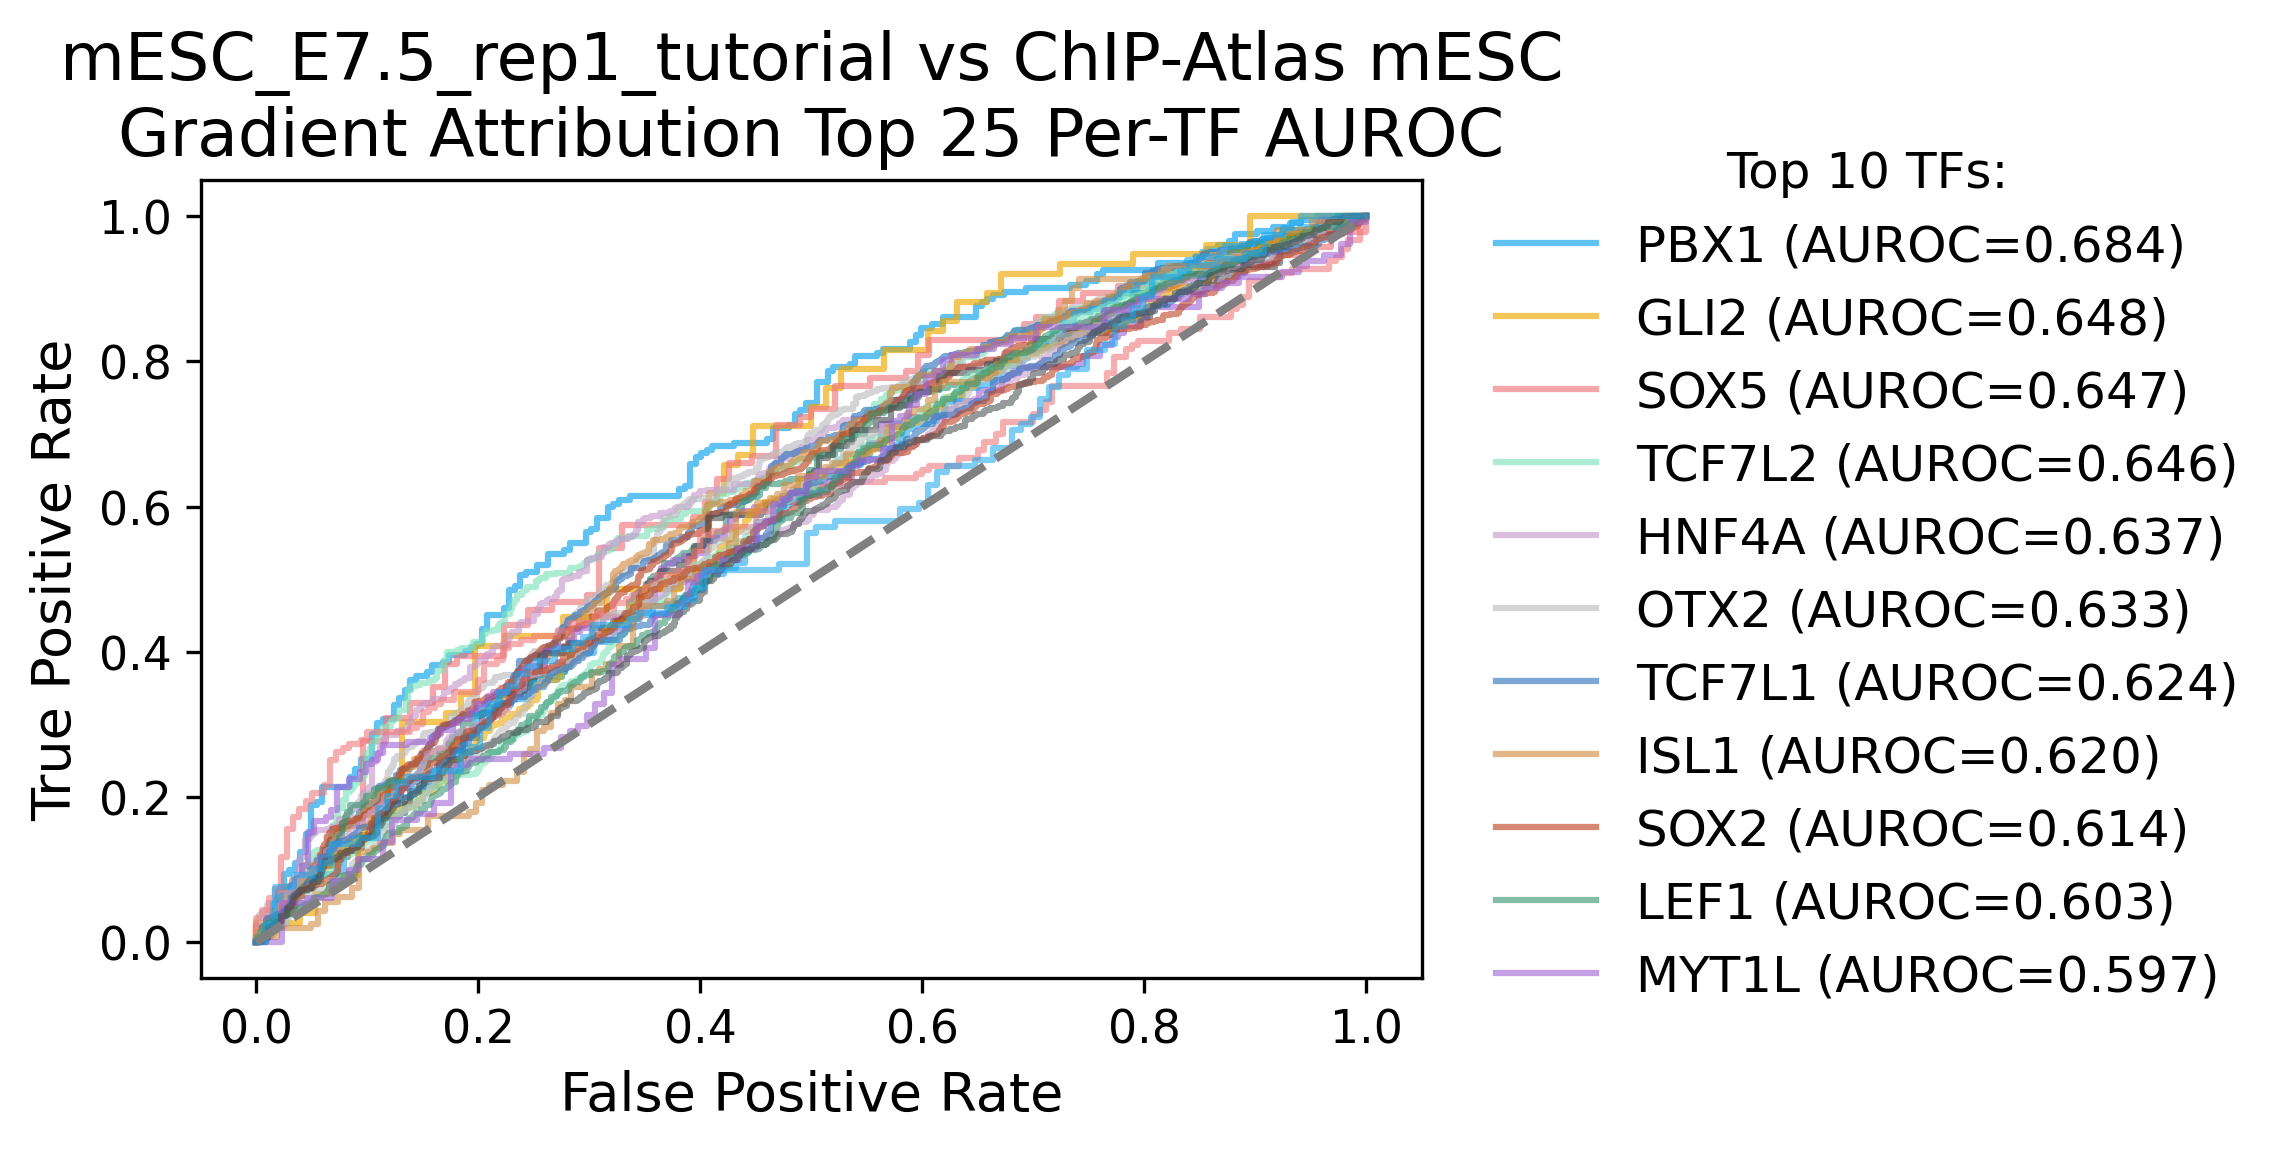

In [65]:
tf_tg_grn_score_df = tf_tg_grn.rename(columns={"tf_tg_grad_score": "Score"})
tf_tg_auroc_df = calculate_auroc_all_sample_gts(exp, tf_tg_grn_score_df, gt_by_dataset_dict["mESC"])
output = exp.plot_top_n_tf_roc_curves(tf_tg_grn_score_df, gt_by_dataset_dict["mESC"]["ChIP-Atlas mESC"], ground_truth_name="ChIP-Atlas mESC", exp=exp)

for gt_name, ground_truth in gt_by_dataset_dict[cell_type].items():
    gt_df, gt_lookup = ground_truth
    gt_tfs, gt_targets, gt_pairs = gt_lookup

    grn_tfs = set(tf_tg_grn["Source"].astype(str).str.upper())
    grn_targets = set(tf_tg_grn["Target"].astype(str).str.upper())

    print()
    print(gt_name)
    print("  overlapping TFs:", len(grn_tfs & gt_tfs))
    print("  overlapping targets:", len(grn_targets & gt_targets))

print("AUROC for TF-TG Gradinet Attribution:")
print(f"Pooled Median AUROC: {tf_tg_auroc_df['pooled_median_auroc'].iloc[0]:.4f}")
print(f"Per-TF Median AUROC: {tf_tg_auroc_df['per_tf_median_auroc'].iloc[0]:.4f}")